## The Problem: Large Movie Dataset Review
### Classify movie reviews from IMDB into positive or negative sentiment.
### Download the dataset [here](https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz)

In [20]:
# imports

from gensim.models import KeyedVectors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import text_dataset_from_directory # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.layers import Embedding, Dense, Input, GlobalAveragePooling1D # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.utils import plot_model # type: ignore

import utils

## Exploring the data

In [2]:
# Importing & preprocessing the dataset
train_path = r'C:\Users\arnig\Documents\Coding_2024\python_work\UpGrad\DS_C70\Specialization_NLP\Semantic-Processing\semantic_processing_upgrad\Distributional Semantics\data\aclImdb_v1\aclImdb\train'
test_path = r'C:\Users\arnig\Documents\Coding_2024\python_work\UpGrad\DS_C70\Specialization_NLP\Semantic-Processing\semantic_processing_upgrad\Distributional Semantics\data\aclImdb_v1\aclImdb\test'

train_ds = text_dataset_from_directory(train_path)
test_ds = text_dataset_from_directory(test_path)

dfTrain = pd.DataFrame(train_ds.unbatch().as_numpy_iterator(), columns=['text', 'label'])
dfTest = pd.DataFrame(test_ds.unbatch().as_numpy_iterator(), columns=['text', 'label'])
_, xts = train_test_split(dfTest, stratify=dfTest['label'], test_size=0.25)

dfTrain['text'] = dfTrain['text'].map(lambda x: x.decode())
xts['text'] = xts['text'].map(lambda x: x.decode())

Found 75000 files belonging to 3 classes.
Found 25000 files belonging to 2 classes.


In [3]:
# train_ds is a tf.data.Dataset object
# test_ds is a tf.data.Dataset object
print(type(train_ds))
print(type(test_ds))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [4]:
pd.options.display.max_colwidth = 200
dfTrain.sample(n=5)

,text,label
72988,Saw this movie on its release and have treasured it since. What a wonderful group of actors (I always find the casting one of the most interesting aspects of a film). Really enjoyed seeing dramati...,1
59135,i 've read some very bad reviews about this movie.. but hey people.. this movie isn't about a great storyline etc.. It's just about some entertainment...<br /><br />but i would suggest to watch th...,2
60464,"May or may not contain spoilers. <br /><br />Inuyasha is not a good anime. It's actually very overrated. Why? There's absolutely no story line, no plot, and the show just drags on... and on... and...",2
45693,"For the most part THE BOX is not a bad film but its not a very good film either, plainly put I had mixed reactions about this film, it had a good concept, the acting was above par, it maintains a ...",2
69549,"I'm taking about the cover of the Troma DVD box. There is like NOTHING accurate about that except that the woman on it looks like the actress. Other than that, nothing. There's a body hanging from...",2


In [5]:
print(dfTrain.loc[0, 'text'])

a friend of mine bought this (very cheaply) and decided to give it to me as a birthday present. i thought i'd never watch it 'cause i knew it was a joke and the cover of the DVD looked pathetic, but then my friends and i got really bored and watched it. from start till finish! i know quite an accomplishment but it really is a masterpiece. it's hard to describe. you should see it, it's a real lesson on what people are capable of when they believe they're creative and smart and really aren't. The "acting" is sous-terrain (you can actually see the "leading lady" laugh on some occasions, she's definitely the worst). the "story" is to stupid to be summed up and really everything in this film sucked. please, pay special attention to "the sheriff". the guy is an adult and therefor has absolutely no excuse to be involved in this. he's extremely bad as well. whatever it did have some hilarious moments. check it out, haha


## Tokenize the text

In [ ]:
tokenizer = Tokenizer()            # create instance
tokenizer.fit_on_texts(dfTrain['text'].tolist())        # fit on list of train sentences
train_sequences = tokenizer.texts_to_sequences(dfTrain['text'].tolist())    # transform train sentences
test_sequences = tokenizer.texts_to_sequences(xts['text'].tolist())         # transform test sentences


word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 153845 unique tokens.


In [8]:
print(train_sequences[0])

[3, 448, 4, 1879, 1283, 11, 52, 6523, 2, 884, 5, 198, 9, 5, 70, 14, 3, 3551, 954, 10, 195, 487, 111, 105, 9, 7136, 10, 694, 9, 13, 3, 1012, 2, 1, 1049, 4, 1, 283, 583, 1170, 18, 94, 59, 362, 2, 10, 192, 64, 1073, 2, 304, 9, 35, 366, 2136, 1447, 10, 121, 178, 32, 8946, 18, 9, 64, 6, 3, 985, 43, 245, 5, 1667, 22, 141, 65, 9, 43, 3, 143, 2191, 20, 48, 81, 23, 2106, 4, 51, 33, 263, 506, 1610, 2, 1261, 2, 64, 713, 1, 116, 6, 33006, 10138, 22, 66, 161, 65, 1, 989, 847, 445, 20, 46, 4825, 458, 400, 1, 249, 1, 63, 6, 5, 375, 5, 26, 7661, 53, 2, 64, 282, 8, 11, 19, 2145, 594, 958, 303, 669, 5, 1, 2020, 1, 225, 6, 32, 1187, 2, 16200, 44, 431, 54, 1411, 5, 26, 572, 8, 11, 223, 559, 74, 14, 69, 834, 9, 118, 25, 46, 616, 377, 831, 9, 42, 10593]


In [ ]:
# Reverse engineer to get sentences back
print([tokenizer.index_word[k] for k in train_sequences[0]])

['a', 'friend', 'of', 'mine', 'bought', 'this', 'very', 'cheaply', 'and', 'decided', 'to', 'give', 'it', 'to', 'me', 'as', 'a', 'birthday', 'present', 'i', 'thought', "i'd", 'never', 'watch', 'it', "'cause", 'i', 'knew', 'it', 'was', 'a', 'joke', 'and', 'the', 'cover', 'of', 'the', 'dvd', 'looked', 'pathetic', 'but', 'then', 'my', 'friends', 'and', 'i', 'got', 'really', 'bored', 'and', 'watched', 'it', 'from', 'start', 'till', 'finish', 'i', 'know', 'quite', 'an', 'accomplishment', 'but', 'it', 'really', 'is', 'a', 'masterpiece', "it's", 'hard', 'to', 'describe', 'you', 'should', 'see', 'it', "it's", 'a', 'real', 'lesson', 'on', 'what', 'people', 'are', 'capable', 'of', 'when', 'they', 'believe', "they're", 'creative', 'and', 'smart', 'and', 'really', "aren't", 'the', 'acting', 'is', 'sous', 'terrain', 'you', 'can', 'actually', 'see', 'the', 'leading', 'lady', 'laugh', 'on', 'some', 'occasions', "she's", 'definitely', 'the', 'worst', 'the', 'story', 'is', 'to', 'stupid', 'to', 'be', 's

In [12]:
MAX_SEQUENCE_LENGTH = max([max(map(len, train_sequences)), max(map(len, test_sequences))])

In [ ]:
MAX_SEQUENCE_LENGTH     # max of both train and test set (this is needed to set dimension of input vector)

2493

In [ ]:
# Train and test data are padded uniform length word-index sequences
train_data = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH)
test_data = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH)

In [15]:
print([tokenizer.index_word.get(k, '<PAD>') for k in train_data[0]])

['<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 

# Train a classifier with Word Embeddings

In [ ]:
countries_wiki = KeyedVectors.load('wiki-countries.w2v')    # import pre-trained word vector ()

In [ ]:
# Using countries_wiki word vector to create word embeddings
embedding_layer = utils.make_embedding_layer(countries_wiki, tokenizer, MAX_SEQUENCE_LENGTH)
countries_wiki_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32'),     # Input layer
    embedding_layer,                                        # Embedding layer
    GlobalAveragePooling1D(),                               # GAP layer (transforms word vectors to sentence vectors)
    Dense(128, activation='relu'),                          # Hidden layer 1
    Dense(64, activation='relu'),                           # Hidden layer 2
    Dense(1, activation='sigmoid')                          # Output layer
])
countries_wiki_model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

c:\Users\arnig\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


#### Visualizing NN

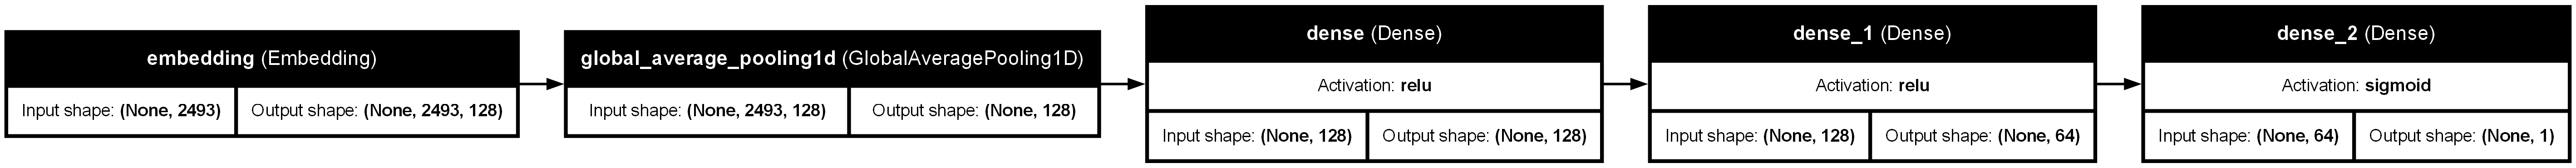

In [35]:
plot_model(countries_wiki_model, 
           show_shapes= True, 
           show_layer_names= True, 
           show_layer_activations= True, 
           rankdir='LR',
           expand_nested= True,
           )

In [36]:
countries_wiki_history = countries_wiki_model.fit(
    train_data, dfTrain['label'].values,
    validation_data=(test_data, xts['label'].values),
    batch_size=64, epochs=30
)

Epoch 1/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.1673 - loss: -3314.5264 - val_accuracy: 0.5000 - val_loss: 52218.3125
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1661 - loss: -106988.9219 - val_accuracy: 0.5000 - val_loss: 350455.0312
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1670 - loss: -489454.5938 - val_accuracy: 0.5000 - val_loss: 1000608.8125
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1674 - loss: -1253662.6250 - val_accuracy: 0.5000 - val_loss: 2059570.8750
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1658 - loss: -2442499.7500 - val_accuracy: 0.5000 - val_loss: 3574826.2500
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1679 - loss: -4177089.2500 - val_accuracy: 0.5000 - val_loss: 5593140.0000
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1645 - loss: -6400590.0000 - val_accuracy: 0.5000 - val_loss: 8167323.5000
Epoch 8

In [52]:
label_pred = pd.Series(countries_wiki_model.predict(test_data).reshape(-1))
label = xts['label'].reset_index(drop= True)

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(label, label_pred))
print(classification_report(label, label_pred))

[[   0 3125]
 [   0 3125]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3125
           1       0.50      1.00      0.67      3125

    accuracy                           0.50      6250
   macro avg       0.25      0.50      0.33      6250
weighted avg       0.25      0.50      0.33      6250



c:\Users\arnig\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\arnig\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\arnig\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

# Train with a different set of word embeddings

## GloVe: Global Vectors for Word Representation
### Download [here](http://nlp.stanford.edu/data/glove.6B.zip)

In [15]:
glove_wiki = KeyedVectors.load_word2vec_format('data/glove.6B/glove.6B.300d.txt', binary=False, no_header=True)

In [16]:
embedding_layer = utils.make_embedding_layer(glove_wiki, tokenizer, MAX_SEQUENCE_LENGTH)

glove_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32'),
    embedding_layer,
    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
glove_model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])

In [17]:
glove_history = glove_model.fit(
    train_data, dfTrain['label'].values,
    validation_data=(test_data, xts['label'].values),
    batch_size=32, epochs=30
)

Epoch 1/30
2344/2344 [==============================] - 81s 33ms/step - loss: -50649.3477 - accuracy: 0.1667 - val_loss: 184496.8906 - val_accuracy: 0.5000
Epoch 2/30
2344/2344 [==============================] - 85s 36ms/step - loss: -566044.8125 - accuracy: 0.1667 - val_loss: 1068684.7500 - val_accuracy: 0.5000
Epoch 3/30
2344/2344 [==============================] - 76s 32ms/step - loss: -1918321.1250 - accuracy: 0.1667 - val_loss: 2877956.5000 - val_accuracy: 0.5000
Epoch 4/30
2344/2344 [==============================] - 75s 32ms/step - loss: -4323605.0000 - accuracy: 0.1667 - val_loss: 5836816.5000 - val_accuracy: 0.5000
Epoch 5/30
2344/2344 [==============================] - 80s 34ms/step - loss: -8016980.5000 - accuracy: 0.1667 - val_loss: 10163823.0000 - val_accuracy: 0.5000
Epoch 6/30
2344/2344 [==============================] - 83s 35ms/step - loss: -13169944.0000 - accuracy: 0.1667 - val_loss: 16015656.0000 - val_accuracy: 0.5000
Epoch 7/30
2344/2344 [=========================

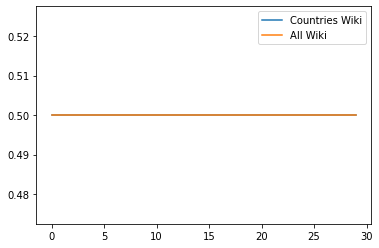

In [18]:
plt.plot(countries_wiki_history.history['val_accuracy'], label='Countries Wiki')
plt.plot(glove_history.history['val_accuracy'], label='All Wiki')
plt.legend()